In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Results

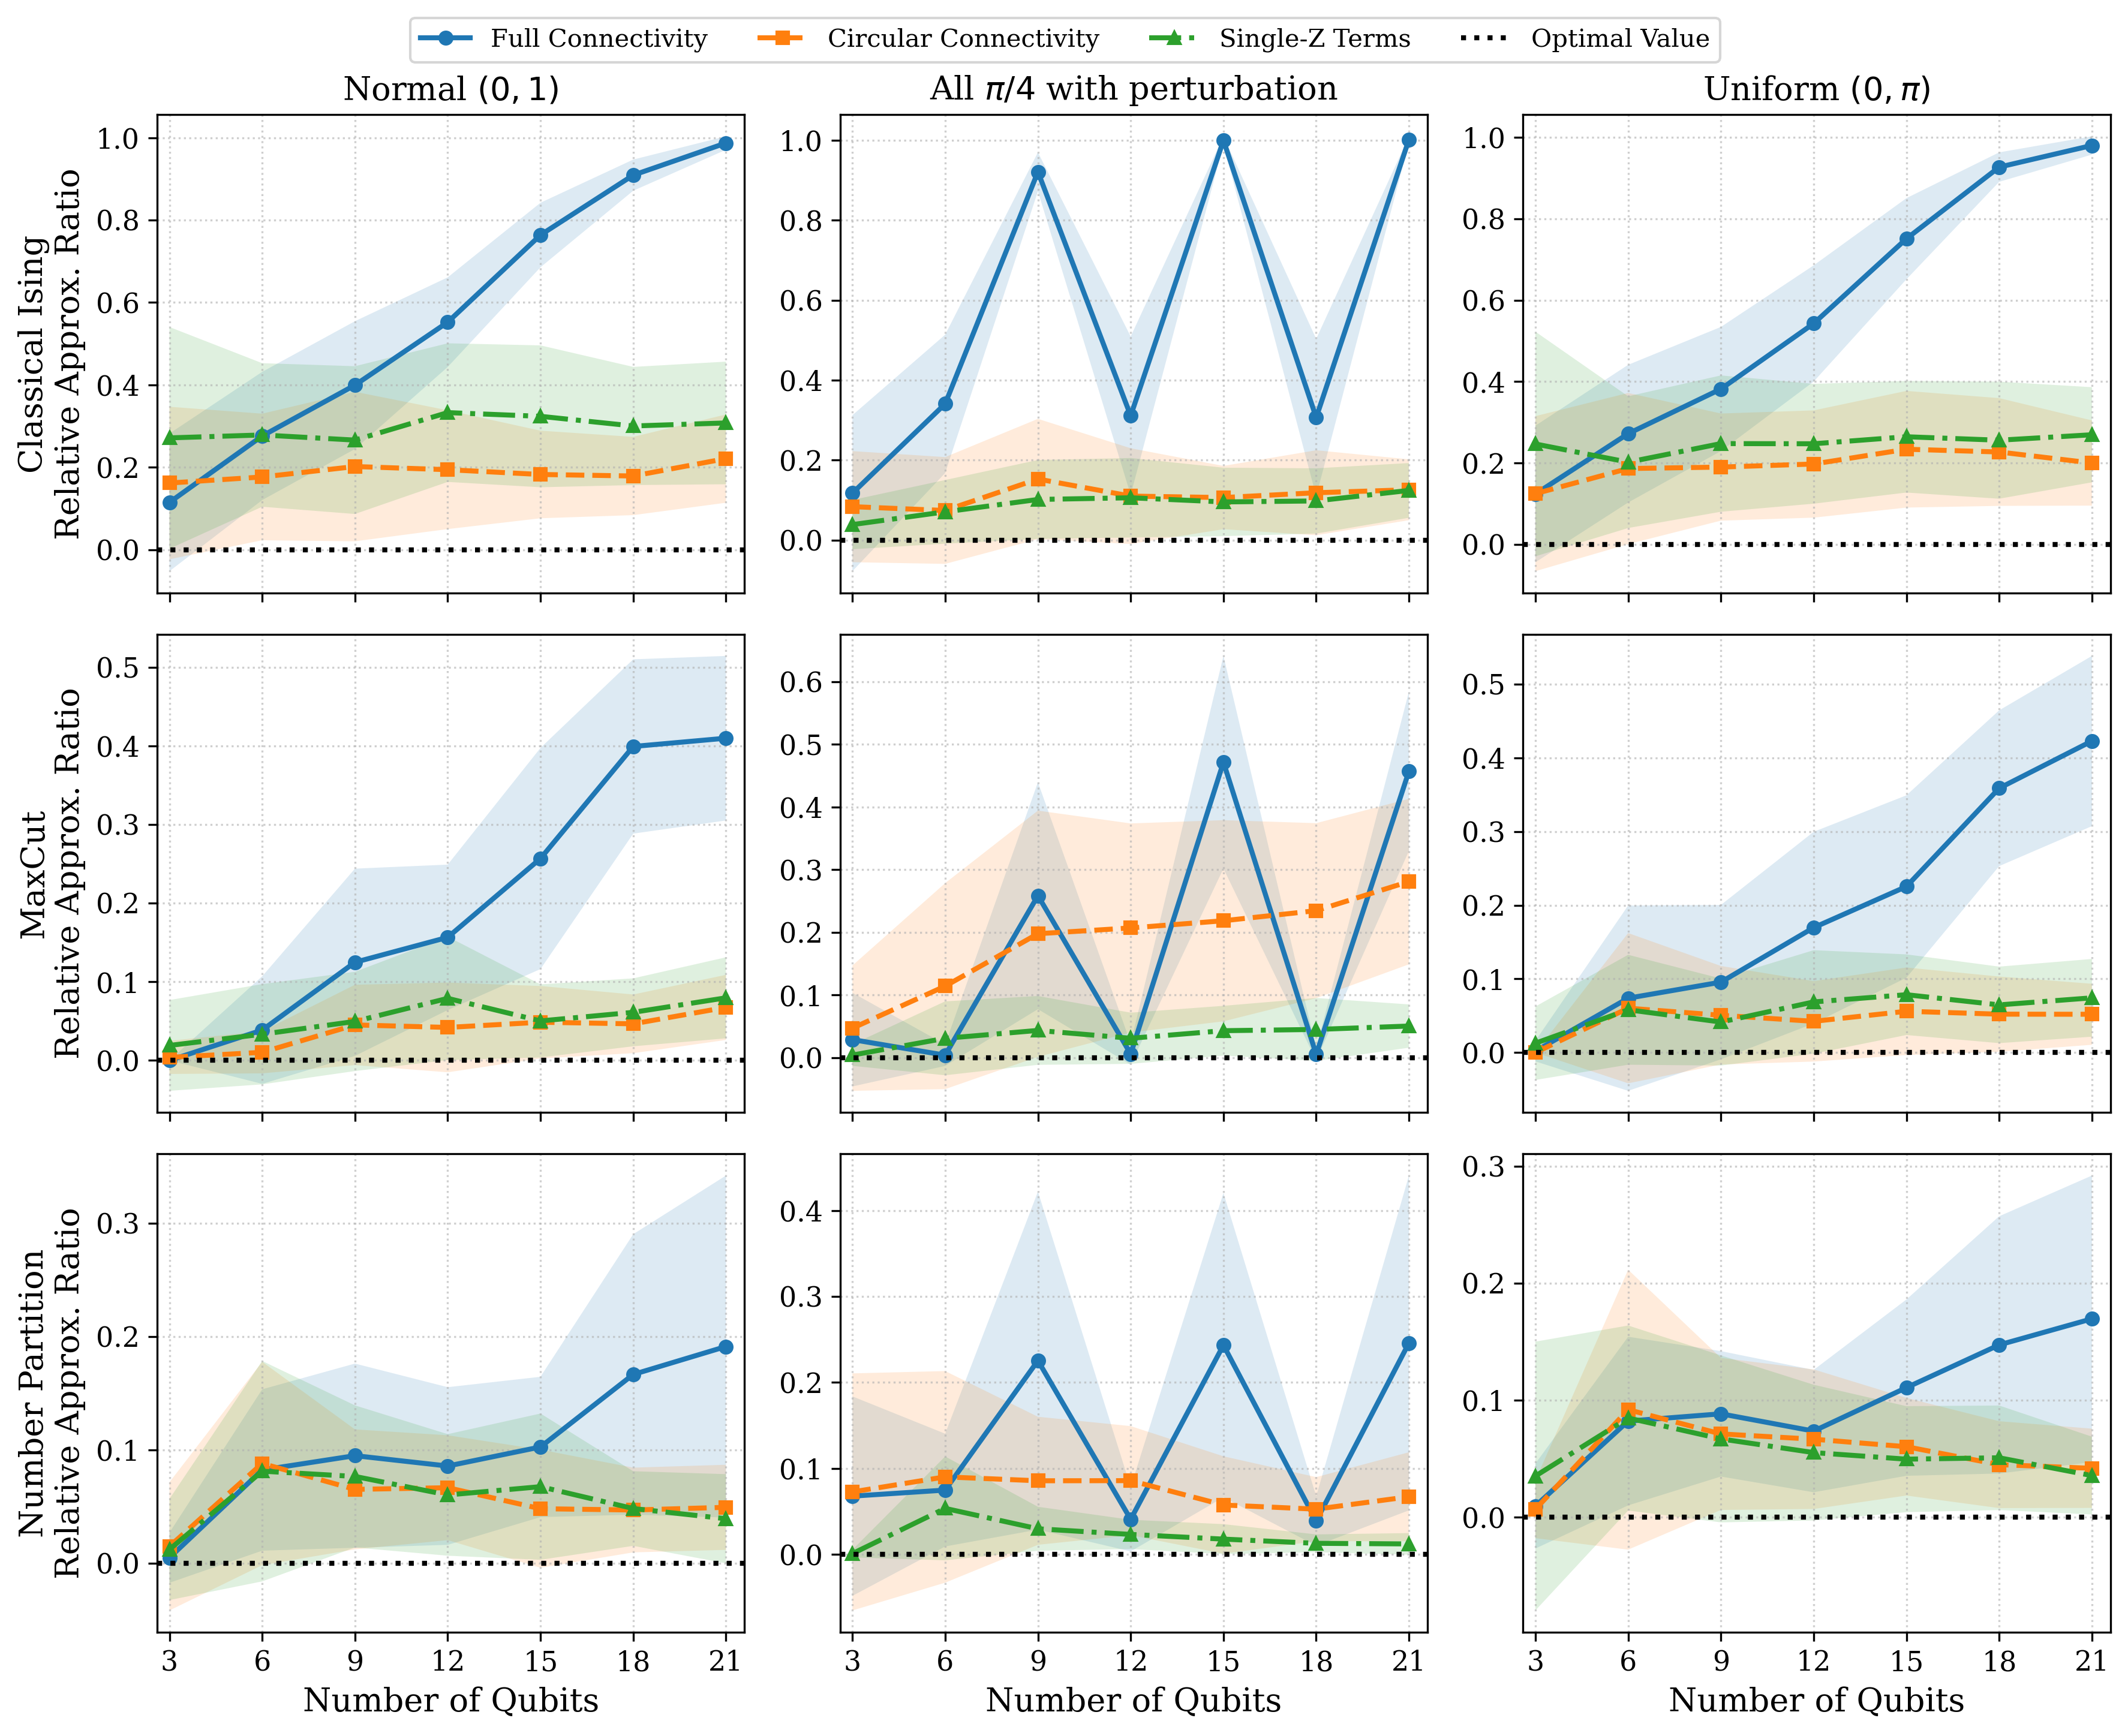

In [7]:
# =====================================================
# Load data
# =====================================================

files = {

    "Classical Ising": {
        "Normal $(0,1)$": "ising_ratio_normal.json",
        r"All $\pi/4$ with perturbation": "ising_ratio_pi4.json",
        r"Uniform $(0,\pi)$": "ising_ratio_uniform.json"
    },

    "MaxCut": {
        "Normal $(0,1)$": "maxcut_ratio_normal.json",
        r"All $\pi/4$ with perturbation": "maxcut_ratio_pi4.json",
        r"Uniform $(0,\pi)$": "maxcut_ratio_uniform.json"
    },

    "Number Partition": {
        "Normal $(0,1)$": "partition_ratio_normal.json",
        r"All $\pi/4$ with perturbation": "partition_ratio_pi4.json",
        r"Uniform $(0,\pi)$": "partition_ratio_uniform.json"
    }

}

datasets = {}

for hamiltonian in files:

    datasets[hamiltonian] = {}

    for initialization, filename in files[hamiltonian].items():

        with open(filename, "r") as f:
            datasets[hamiltonian][initialization] = json.load(f)

# =====================================================
# Publication style
# =====================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

styles = {
    "full": {
        "label": "Full Connectivity",
        "marker": "o",
        "linestyle": "-"
    },
    "circular": {
        "label": "Circular Connectivity",
        "marker": "s",
        "linestyle": "--"
    },
    "single": {
        "label": "Single-Z Terms",
        "marker": "^",
        "linestyle": "-."
    }
}

hamiltonians = list(files.keys())
initializations = list(next(iter(files.values())).keys())

# =====================================================
# Create 3×3 figure
# =====================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 10),
    sharex=True,
    # sharey=True
)

for i, hamiltonian in enumerate(hamiltonians):

    for j, initialization in enumerate(initializations):

        ax = axes[i, j]

        data = datasets[hamiltonian][initialization]

        for structure in ["full", "circular", "single"]:

            qubits = sorted(map(int, data[structure].keys()))

            # Mean over 50 runs
            mean = np.array([
                np.mean(data[structure][str(q)])
                for q in qubits
            ])
            
            # Standard deviation over 50 runs
            std = np.array([
                np.std(data[structure][str(q)])
                for q in qubits
            ])

            # Use 95% CI instead
            # std = 1.96 * std / np.sqrt(50)

            ax.plot(
                qubits,
                mean,
                marker=styles[structure]["marker"],
                linestyle=styles[structure]["linestyle"],
                linewidth=2,
                markersize=5,
                label=styles[structure]["label"]
            )

            ax.fill_between(
                qubits,
                mean - std,
                mean + std,
                alpha=0.15
            )

        ax.grid(True, linestyle=":", alpha=0.6)

        ax.axhline(
            y=0,
            color="black",
            linestyle=":",
            linewidth=2,
            label='Optimal Value'
        )

        ax.set_xlim(2.6, 21.6)
        ax.set_xticks(np.arange(3, 22, 3))

        # column titles
        if i == 0:
            ax.set_title(initialization)

        # row labels
        if j == 0:
            ax.set_ylabel(
                hamiltonian + "\nRelative Approx. Ratio"
            )

        # x labels only on bottom row
        if i == 2:
            ax.set_xlabel("Number of Qubits")

# =====================================================
# Shared legend
# =====================================================

handles, labels = axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=4,
    frameon=True
)

plt.tight_layout(rect=[0,0,1,0.95])

# plt.suptitle("Comparison of different Hamiltonians with different Initializations \n (1000 iterations, 50 problem samples, and 1000 Monte Carlo sampling for each configuration)", y=1.05)

plt.savefig(
    "IQP_all_hamiltonians.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

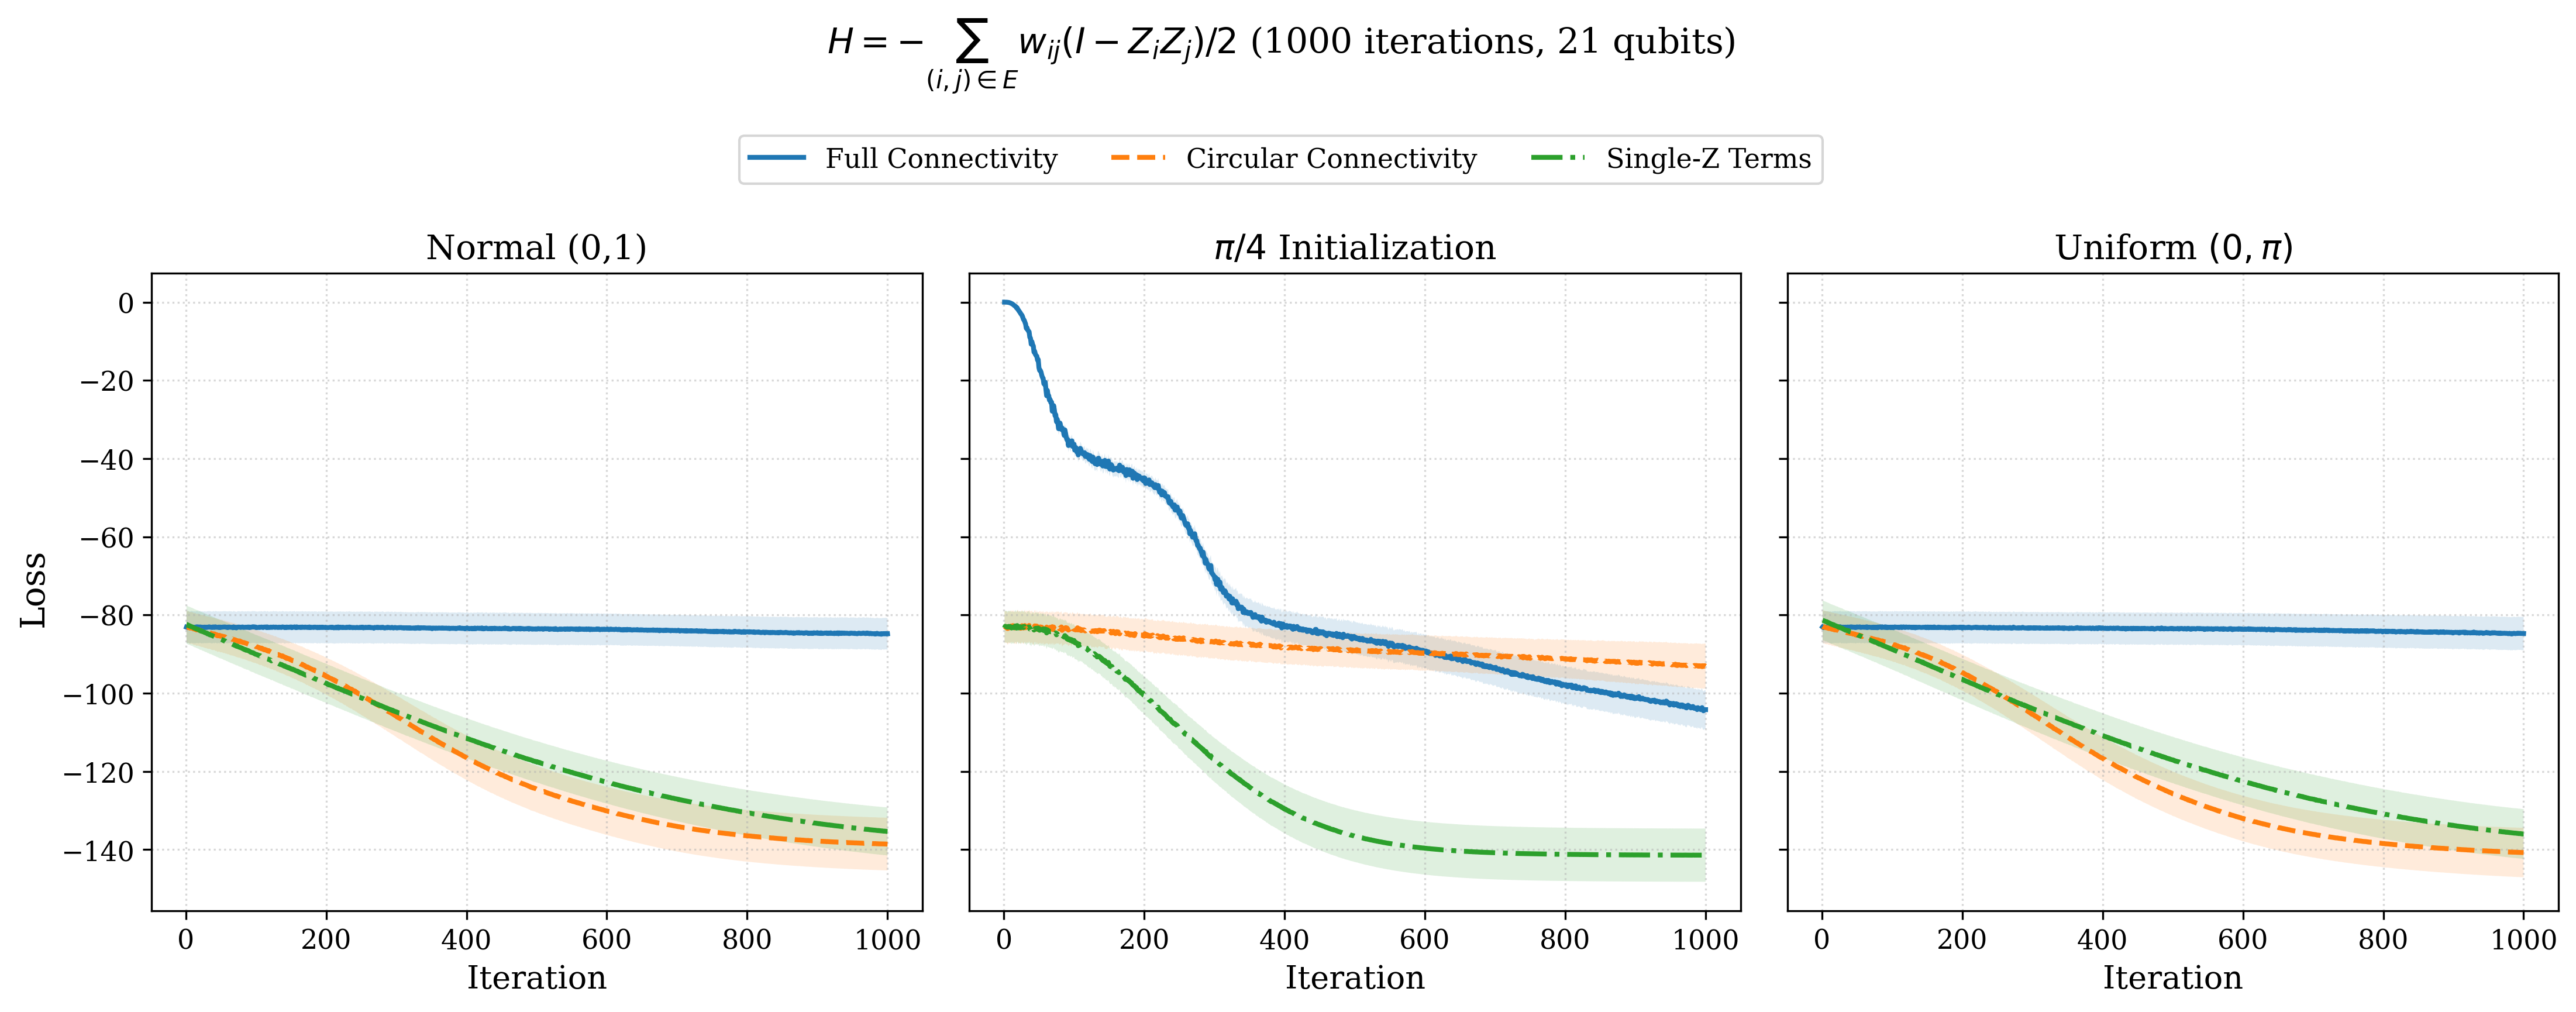

In [10]:
# ======================================================
# Load data
# ======================================================

with open("maxcut_loss_normal.json", "r") as f:
    normal = json.load(f)

with open("maxcut_loss_uniform.json", "r") as f:
    uniform = json.load(f)

with open("maxcut_loss_pi4.json", "r") as f:
    pi4 = json.load(f)

normal = {'single': normal['single']['21'], 
          'circular': normal['circular']['21'], 
          'full': normal['full']['21']}
uniform = {'single': uniform['single']['21'], 
          'circular': uniform['circular']['21'], 
          'full': uniform['full']['21']}
pi4 = {'single': pi4['single']['21'], 
          'circular': pi4['circular']['21'], 
          'full': pi4['full']['21']}

datasets = {
    "Normal (0,1)": normal,
    r"$\pi/4$ Initialization": pi4,
    r"Uniform $(0,\pi)$": uniform
}

# ======================================================
# Figure style
# ======================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

styles = {
    "full": {
        "label": "Full Connectivity",
        "linestyle": "-"
    },
    "circular": {
        "label": "Circular Connectivity",
        "linestyle": "--"
    },
    "single": {
        "label": "Single-Z Terms",
        "linestyle": "-."
    }
}

# ======================================================
# Create subplots
# ======================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharey=True
)

for ax, (title, data) in zip(axes, datasets.items()):

    for architecture in ["full", "circular", "single"]:

        # shape = (21, 1000)
        runs = np.array(data[architecture])

        mean_loss = np.mean(runs, axis=0)

        # 95% confidence interval
        n_runs = runs.shape[0]
        ci = 1.96 * np.std(runs, axis=0) / np.sqrt(n_runs)

        iterations = np.arange(1, len(mean_loss) + 1)

        ax.plot(
            iterations,
            mean_loss,
            linewidth=2,
            linestyle=styles[architecture]["linestyle"],
            label=styles[architecture]["label"]
        )

        ax.fill_between(
            iterations,
            mean_loss - ci,
            mean_loss + ci,
            alpha=0.15
        )

    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.grid(True, linestyle=":", alpha=0.5)

    # Optional: logarithmic iteration axis
    # ax.set_xscale("log")

# fig.supxlabel("Iteration", fontsize=14)
fig.supylabel("Loss", fontsize=14)

# ======================================================
# Shared legend
# ======================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# ======================================================
# Save figure
# ======================================================

# plt.savefig(
#     "iqp_loss_convergence_three_initializations.pdf",
#     bbox_inches="tight"
# )

plt.suptitle("$H = - \sum_{(i, j) \in E} w_{ij} (I - Z_{i} Z_{j})/2$ (1000 iterations, 21 qubits)", y=1.15)

plt.savefig(
    "iqp_loss_convergence_three_initializations_maxcut.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [49]:
# # =====================================================
# # Load data
# # =====================================================

# files = {
#     "Normal $(0,1)$": "maxcut_ratio_normal.json",
#     r"$\pi/4$": "maxcut_ratio_pi4.json",
#     r"Uniform $(0,\pi)$": "maxcut_ratio_uniform.json",
# }

# datasets = {}

# for name, filename in files.items():
#     with open(filename, "r") as f:
#         datasets[name] = json.load(f)

# # =====================================================
# # Publication style
# # =====================================================

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.size": 12,
#     "axes.labelsize": 13,
#     "axes.titlesize": 14,
#     "legend.fontsize": 10,
#     "xtick.labelsize": 11,
#     "ytick.labelsize": 11,
#     "figure.dpi": 300,
# })

# styles = {
#     "full": {
#         "label": "Full Connectivity",
#         "marker": "o",
#         "linestyle": "-"
#     },
#     "circular": {
#         "label": "Circular Connectivity",
#         "marker": "s",
#         "linestyle": "--"
#     },
#     "single": {
#         "label": "Single-Z Terms",
#         "marker": "^",
#         "linestyle": "-."
#     }
# }

# # =====================================================
# # Create 2x2 figure
# # =====================================================

# fig, axes = plt.subplots(
#     1,
#     3,
#     figsize=(12, 4),
#     sharex=True,
#     sharey=True
# )

# axes = axes.flatten()

# for ax, (init_name, data) in zip(axes, datasets.items()):

#     for structure in ["full", "circular", "single"]:

#         qubits = sorted(map(int, data[structure].keys()))

#         mean = np.array([
#             data[structure][str(q)][0]
#             for q in qubits
#         ])

#         std = np.array([
#             data[structure][str(q)][1]
#             for q in qubits
#         ])

#         # std = 1.96 * std / np.sqrt(30)

#         ax.plot(
#             qubits,
#             mean,
#             marker=styles[structure]["marker"],
#             linestyle=styles[structure]["linestyle"],
#             linewidth=2,
#             markersize=6,
#             label=styles[structure]["label"]
#         )

#         ax.fill_between(
#             qubits,
#             mean - std,
#             mean + std,
#             alpha=0.15
#         )

#     ax.set_title(init_name)
#     ax.grid(True, linestyle=":", alpha=0.6)

#     ax.axhline(
#     y=0,
#     color="black",
#     linestyle=":",
#     linewidth=1
# )
    
#     ax.set_xlim(2.6, 21.6)
#     ax.set_xticks(np.arange(3, 22, 3))
#     ax.set_xlabel("Number of Qubits")

# # =====================================================
# # Shared labels
# # =====================================================

# # fig.supxlabel("Number of Qubits", fontsize=14)
# fig.supylabel("Approximation Ratio", fontsize=14)

# # =====================================================
# # Single legend for entire figure
# # =====================================================

# handles, labels = axes[0].get_legend_handles_labels()

# fig.legend(
#     handles,
#     labels,
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.02),
#     ncol=3,
#     frameon=True
# )

# plt.tight_layout(rect=[0, 0, 1, 0.95])

# # =====================================================
# # Save high-quality figures
# # =====================================================

# # plt.savefig(
# #     "iqp_initialization_comparison.pdf",
# #     bbox_inches="tight"
# # )

# plt.suptitle("$H = - \sum_{(i, j) \in E} w_{ij} (I - Z_{i} Z_{j})/2$ (1000 iterations), ratio = $|f(x) - f(x^{*})| / f(x^{*})$", y=1.15)

# # plt.savefig(
# #     "iqp_initialization_comparison_maxcut.png",
# #     dpi=600,
# #     bbox_inches="tight"
# # )
# plt.show()

In [60]:
# import json
# import itertools
# import pandas as pd
# from scipy.stats import kruskal, mannwhitneyu

# # =====================================================
# # Load JSON files
# # =====================================================

# with open("output_normal.json", "r") as f:
#     normal = json.load(f)

# with open("output_pi4.json", "r") as f:
#     pi4 = json.load(f)

# with open("output_random.json", "r") as f:
#     uniform = json.load(f)

# # with open("zero_results.json", "r") as f:
# #     zero = json.load(f)

# datasets = {
#     "normal": normal,
#     "pi4": pi4,
#     "uniform": uniform,
#     # "zero": zero
# }

# # =====================================================
# # Kruskal-Wallis test
# # =====================================================

# kruskal_rows = []

# for architecture in ["full", "circular", "single"]:

#     qubits = sorted(map(int, normal[architecture].keys()))

#     for q in qubits:

#         groups = [
#             normal[architecture][str(q)],
#             pi4[architecture][str(q)],
#             uniform[architecture][str(q)],
#             # zero[architecture][str(q)]
#         ]

#         H, p = kruskal(*groups)

#         kruskal_rows.append({
#             "architecture": architecture,
#             "qubits": q,
#             "H_statistic": H,
#             "p_value": p,
#             "significant": p < 0.05
#         })

# kruskal_df = pd.DataFrame(kruskal_rows)

# print("\nKruskal-Wallis Results")
# print(kruskal_df)

# kruskal_df.to_csv(
#     "kruskal_initialization_results.csv",
#     index=False
# )

# # =====================================================
# # Pairwise Mann-Whitney U tests
# # =====================================================

# pairwise_rows = []

# initializations = list(datasets.keys())

# for architecture in ["full", "circular", "single"]:

#     qubits = sorted(map(int, normal[architecture].keys()))

#     for q in qubits:

#         for init1, init2 in itertools.combinations(initializations, 2):

#             x = datasets[init1][architecture][str(q)]
#             y = datasets[init2][architecture][str(q)]

#             U, p = mannwhitneyu(
#                 x,
#                 y,
#                 alternative="two-sided"
#             )

#             pairwise_rows.append({
#                 "architecture": architecture,
#                 "qubits": q,
#                 "comparison": f"{init1} vs {init2}",
#                 "U_statistic": U,
#                 "p_value": p
#             })

# pairwise_df = pd.DataFrame(pairwise_rows)

# # Bonferroni correction
# alpha = 0.05
# bonferroni_alpha = alpha / 6

# pairwise_df["significant"] = (
#     pairwise_df["p_value"] < bonferroni_alpha
# )

# print("\nPairwise Mann-Whitney Results")
# print(pairwise_df)

# pairwise_df.to_csv(
#     "pairwise_initialization_results.csv",
#     index=False
# )

# print(f"\nBonferroni threshold = {bonferroni_alpha:.5f}")

# Circuit

In [2]:
import pennylane as qp
import pennylane.numpy as np
from IQP_circuit import *
from MaxCut import *
from Partition import *
import jax
import json
import jax.numpy as jnp
import matplotlib.pyplot as plt

(<Figure size 6000x1500 with 1 Axes>, <Axes: >)


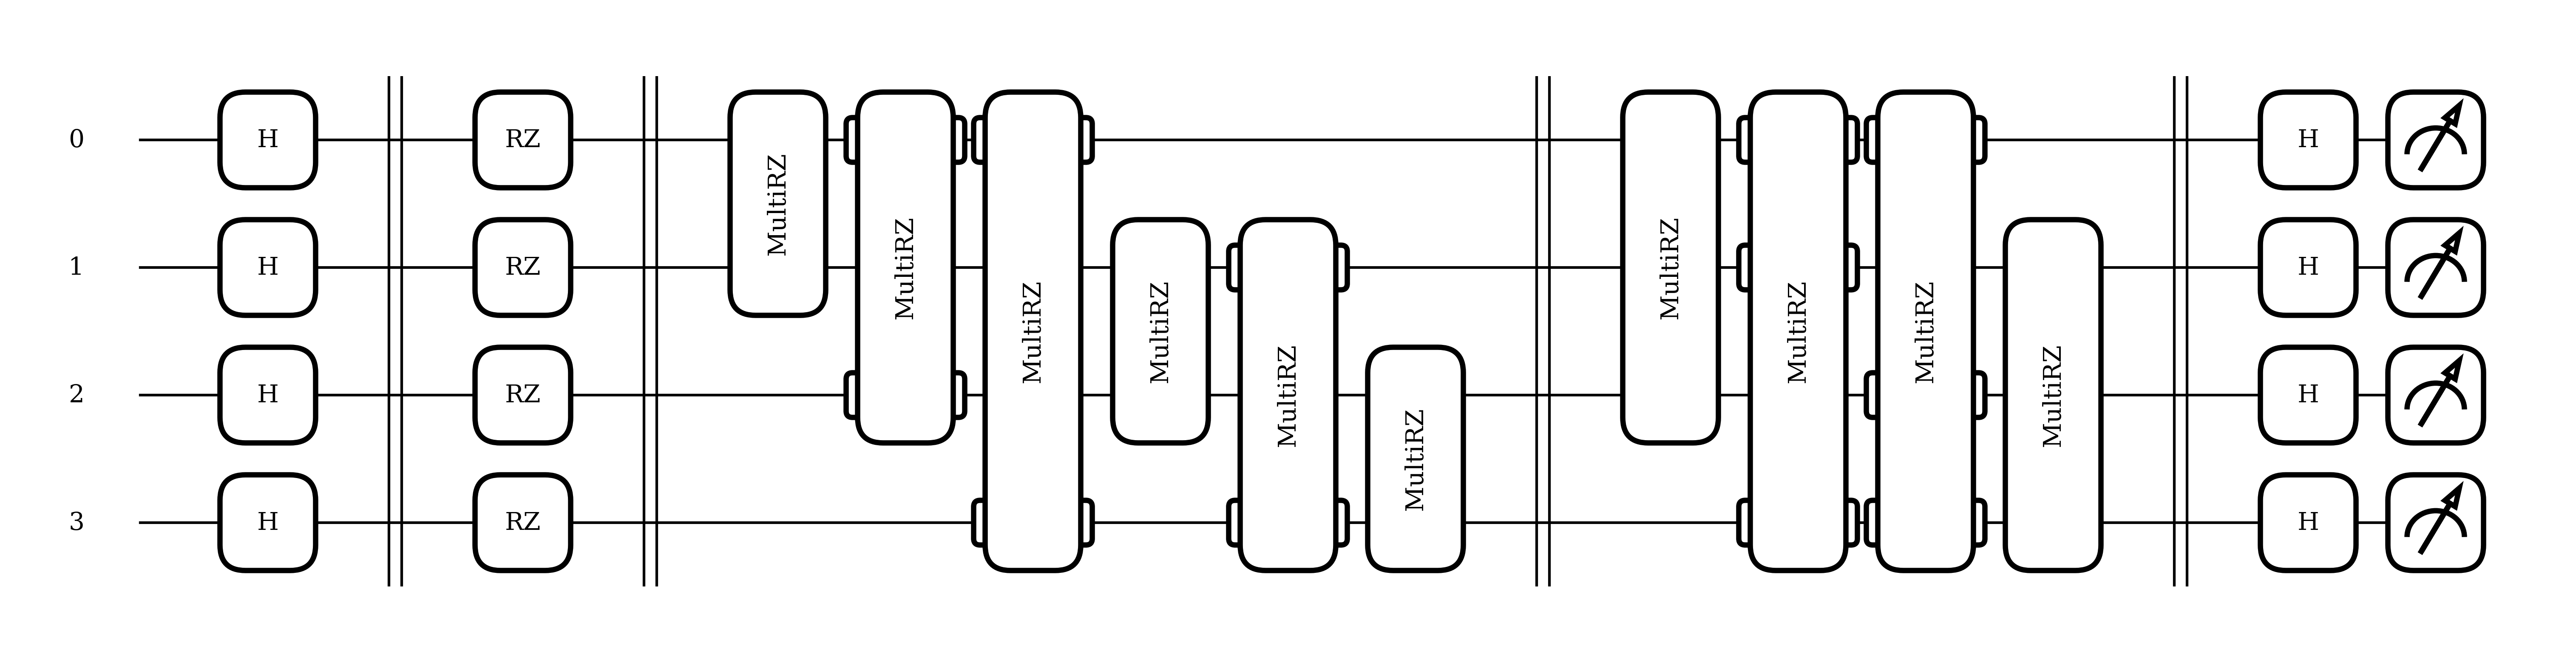

In [67]:
n_qubits = 4
dev = qp.device("default.qubit", wires=n_qubits)

@qp.qnode(dev)
def circuit(params, gates):

    # |+>^n
    for i in range(n_qubits):
        qp.Hadamard(i)

    qp.Barrier()

    for theta, gate in zip(params, gates):

        term = gate[0]

        # single-Z term
        if len(term) == 1:
            qp.RZ(theta, wires=term[0])

    qp.Barrier()

    for theta, gate in zip(params, gates):

        term = gate[0]

        # Z^{n} term
        if len(term) == 2:
            qp.MultiRZ(theta, wires=term)

    qp.Barrier()

    for theta, gate in zip(params, gates):

        term = gate[0]

        # Z^{n} term
        if len(term) == 3:
            qp.MultiRZ(theta, wires=term)

    qp.Barrier()

    # back to basis
    for i in range(n_qubits):
        qp.Hadamard(i)

    return qp.state()

gates_full = gens(4, "triple")
theta = np.random.uniform(0, np.pi, len(gates_full))
# Print circuit
print(qml.draw_mpl(circuit)(theta, gates_full))

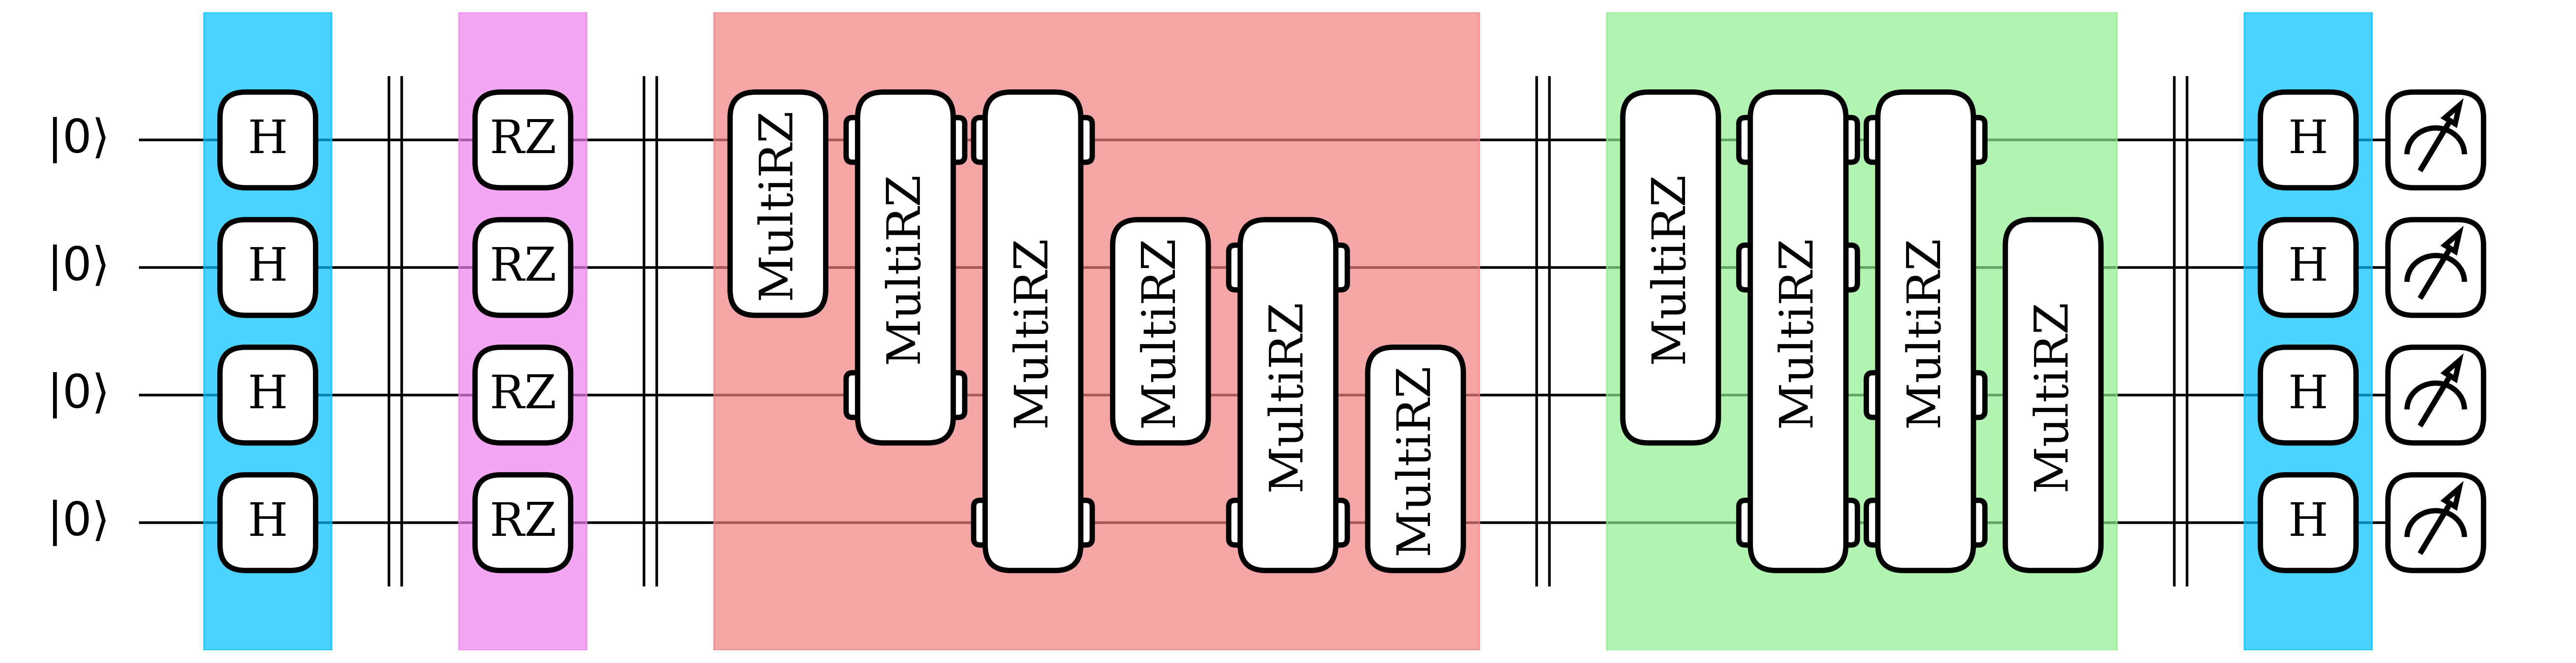

In [70]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

fig, ax = qml.draw_mpl(circuit)(theta, gates_full)

for text in ax.texts:
    text.set_fontsize(26)

for text in ax.texts:
    if text.get_text() in ["0", "1", "2", "3"]:
        text.set_text(r"$|0\rangle$")

# x-ranges depend on your circuit
ax.axvspan(-0.5, 0.5, color="deepskyblue", alpha=0.7)
ax.axvspan(1.5, 2.5, color="violet", alpha=0.7)
ax.axvspan(3.5, 9.5, color="lightcoral", alpha=0.7)
ax.axvspan(10.5, 14.5, color="lightgreen", alpha=0.7)
ax.axvspan(15.5, 16.5, color="deepskyblue", alpha=0.7)
fig.savefig(
    "iqp_circuit.pdf",
    dpi=600,
    bbox_inches="tight")

plt.show()